# PR 5 - Petrofisika Praktikum

**Nama**  : Rifqi Pasha Alviansyah  
**NIM**   : 12224010  
**Kelas** : K-01


## PR Nomor 1

### Langkah 0 : Import dan Data Awal


In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import openpyxl
from openpyxl.drawing.image import Image
import sys

# Data
Sw1 = [0.98, 0.88, 0.70, 0.58, 0.40, 0.25, 0.19, 0.18]
Pc1 = [0.44, 0.58, 1.02, 1.60, 2.76, 5.22, 8.12, 11.31]

Sw2 = [0.98, 0.80, 0.64, 0.48, 0.38, 0.32, 0.26, 0.22, 0.21]
Pc2 = [0.44, 0.73, 1.16, 2.03, 3.34, 4.79, 6.53, 8.85, 10.73]

Sw3 = [0.98, 0.86, 0.72, 0.60, 0.48, 0.40, 0.34, 0.32, 0.25, 0.21]
Pc3 = [0.87, 1.16, 1.45, 1.74, 2.90, 4.21, 5.51, 7.40, 9.72, 12.47]

phi_core = [0.18, 0.20, 0.28]
k_core = [145, 95, 85]
sigma_lab = 25.0
sigma_res = 21.0
rho_w = 1.03
rho_o = 0.82

print("Data siap.")

Data siap.


### Langkah i :  Hitung J(Sw) dari data Pc seluruh core

In [49]:
def hitung_J(pc_list, kc, phic):
    sqrt_k_phi = np.sqrt(kc / phic)
    konst = 0.21645 / sigma_lab
    return konst * np.array(pc_list) * sqrt_k_phi

J1 = hitung_J(Pc1, k_core[0], phi_core[0])
J2 = hitung_J(Pc2, k_core[1], phi_core[1])
J3 = hitung_J(Pc3, k_core[2], phi_core[2])

# Tampilkan tabel per core (karena panjang berbeda)
df_J1 = pd.DataFrame({'Sw': Sw1, 'Pc(psi)': Pc1, 'J': J1})
df_J2 = pd.DataFrame({'Sw': Sw2, 'Pc(psi)': Pc2, 'J': J2})
df_J3 = pd.DataFrame({'Sw': Sw3, 'Pc(psi)': Pc3, 'J': J3})

print("Hasil perhitungan J(Sw) untuk setiap core:")
print("\nCore 1:")
print(df_J1)
print("\nCore 2:")
print(df_J2)
print("\nCore 3:")
print(df_J3)

Hasil perhitungan J(Sw) untuk setiap core:

Core 1:
     Sw  Pc(psi)         J
0  0.98     0.44  0.108123
1  0.88     0.58  0.142526
2  0.70     1.02  0.250649
3  0.58     1.60  0.393174
4  0.40     2.76  0.678226
5  0.25     5.22  1.282732
6  0.19     8.12  1.995360
7  0.18    11.31  2.779252

Core 2:
     Sw  Pc(psi)         J
0  0.98     0.44  0.083027
1  0.80     0.73  0.137749
2  0.64     1.16  0.218888
3  0.48     2.03  0.383054
4  0.38     3.34  0.630247
5  0.32     4.79  0.903857
6  0.26     6.53  1.232190
7  0.22     8.85  1.669966
8  0.21    10.73  2.024716

Core 3:
     Sw  Pc(psi)         J
0  0.98     0.87  0.131240
1  0.86     1.16  0.174987
2  0.72     1.45  0.218734
3  0.60     1.74  0.262481
4  0.48     2.90  0.437468
5  0.40     4.21  0.635082
6  0.34     5.51  0.831189
7  0.32     7.40  1.116297
8  0.25     9.72  1.466271
9  0.21    12.47  1.881111


### Langkah ii :  Plot kurva Pc vs Sw dan J(Sw) vs Sw

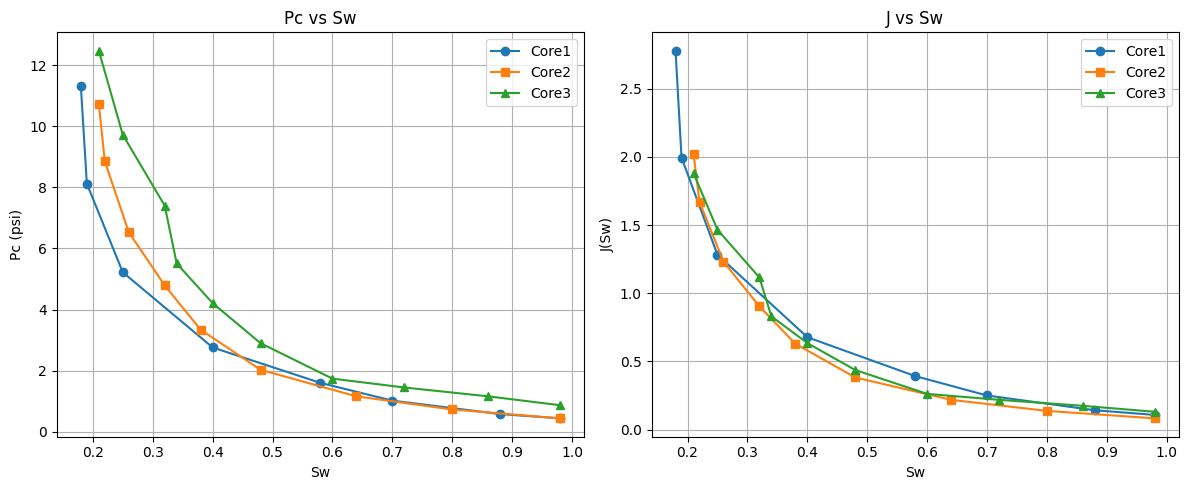

Grafik Pc vs Sw dan J vs Sw telah disimpan.


In [56]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(Sw1, Pc1, 'o-', label='Core1')
plt.plot(Sw2, Pc2, 's-', label='Core2')
plt.plot(Sw3, Pc3, '^-', label='Core3')
plt.xlabel('Sw'); plt.ylabel('Pc (psi)'); plt.title('Pc vs Sw')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(Sw1, J1, 'o-', label='Core1')
plt.plot(Sw2, J2, 's-', label='Core2')
plt.plot(Sw3, J3, '^-', label='Core3')
plt.xlabel('Sw'); plt.ylabel('J(Sw)'); plt.title('J vs Sw')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig('plot_Pc_J.png')
plt.show()
print("Grafik Pc vs Sw dan J vs Sw telah disimpan.")

### Langkah iii :  Tentukan power trendline J(Sw) vs Sw (seluruh data)

Persamaan trendline (power): J = 0.1197 * Sw^-1.7763


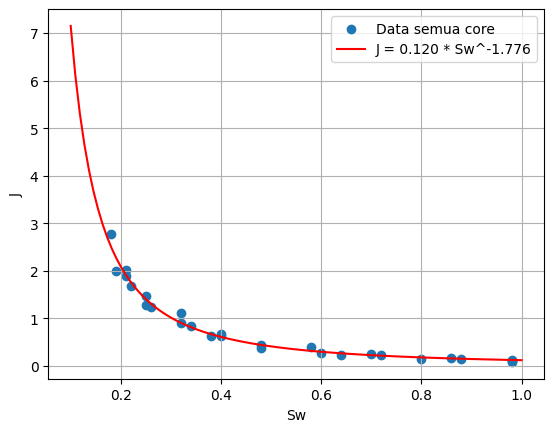

In [62]:
# Gabungkan seluruh data (Sw dan J) dari semua core
Sw_all = Sw1 + Sw2 + Sw3
J_all = list(J1) + list(J2) + list(J3)

def power_func(Sw, a, b):
    return a * Sw**b

popt, _ = curve_fit(power_func, Sw_all, J_all, p0=[0.1, -2])
a, b = popt
print(f"Persamaan trendline (power): J = {a:.4f} * Sw^{b:.4f}")

# Plot data dan trendline
Sw_halus = np.linspace(0.1, 1, 100)
J_halus = power_func(Sw_halus, a, b)

plt.figure()
plt.scatter(Sw_all, J_all, label='Data semua core')
plt.plot(Sw_halus, J_halus, 'r-', label=f'J = {a:.3f} * Sw^{b:.3f}')
plt.xlabel('Sw'); plt.ylabel('J'); plt.legend(); plt.grid(True)
plt.savefig('trendline.png')
plt.show()

### Langkah iv :  Tentukan nilai Sw untuk tabel

In [67]:
Sw_tabel = np.arange(0.1, 1.05, 0.1)
print("Nilai Sw yang digunakan untuk tabel selanjutnya:")
print(Sw_tabel)

Nilai Sw yang digunakan untuk tabel selanjutnya:
[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


### Langkah v :  Hitung J(Sw) dari nilai Sw tersebut (pakai persamaan trendline)

In [74]:
J_tabel = power_func(Sw_tabel, a, b)
df_J_tabel = pd.DataFrame({'Sw': Sw_tabel, 'J_trendline': J_tabel})
print("Hasil J(Sw) dari persamaan trendline:")
print(df_J_tabel)

Hasil J(Sw) dari persamaan trendline:
    Sw  J_trendline
0  0.1     7.150910
1  0.2     2.087511
2  0.3     1.015852
3  0.4     0.609391
4  0.5     0.409969
5  0.6     0.296550
6  0.7     0.225516
7  0.8     0.177895
8  0.9     0.144311
9  1.0     0.119679


### Langkah vi :  Hitung Pc lab dari nilai J(Sw) (persamaan 1) – kondisi lab

In [77]:
# Hitung dulu sqrt(k/phi) rata-rata untuk konversi dari J ke Pc (langkah vii nanti, tapi butuh di sini)
k_avg = np.mean(k_core)
phi_avg = np.mean(phi_core)
sqrt_kphi_avg = np.sqrt(k_avg / phi_avg)

# Pc_lab = J * sigma_lab / (0.21645 * sqrt(k/phi)_avg)
Pc_lab_tabel = J_tabel * sigma_lab / (0.21645 * sqrt_kphi_avg)
df_Pc_lab = pd.DataFrame({'Sw': Sw_tabel, 'J': J_tabel, 'Pc_lab (psi)': Pc_lab_tabel})
print("Hasil Pc laboratorium dari J (menggunakan k dan phi rata-rata):")
print(df_Pc_lab)

Hasil Pc laboratorium dari J (menggunakan k dan phi rata-rata):
    Sw         J  Pc_lab (psi)
0  0.1  7.150910     37.219801
1  0.2  2.087511     10.865294
2  0.3  1.015852      5.287410
3  0.4  0.609391      3.171823
4  0.5  0.409969      2.133848
5  0.6  0.296550      1.543514
6  0.7  0.225516      1.173789
7  0.8  0.177895      0.925926
8  0.9  0.144311      0.751125
9  1.0  0.119679      0.622918


### Langkah vii :  Hitung nilai permeabilitas dan porositas rata-rata

In [79]:
print(f"Permeabilitas rata-rata = {k_avg:.2f} mD")
print(f"Porositas rata-rata = {phi_avg:.4f} fraksi")
print(f"√(k/φ) rata-rata = {sqrt_kphi_avg:.4f}")

Permeabilitas rata-rata = 108.33 mD
Porositas rata-rata = 0.2200 fraksi
√(k/φ) rata-rata = 22.1906


### Langkah viii :  Hitung Pc reservoir (konversi persamaan 2)

In [80]:
Pc_res_tabel = Pc_lab_tabel * (sigma_res / sigma_lab)
df_Pc_res = pd.DataFrame({'Sw': Sw_tabel, 'Pc_lab (psi)': Pc_lab_tabel, 'Pc_res (psi)': Pc_res_tabel})
print("Hasil konversi ke tekanan kapiler reservoir:")
print(df_Pc_res)

Hasil konversi ke tekanan kapiler reservoir:
    Sw  Pc_lab (psi)  Pc_res (psi)
0  0.1     37.219801     31.264633
1  0.2     10.865294      9.126847
2  0.3      5.287410      4.441425
3  0.4      3.171823      2.664331
4  0.5      2.133848      1.792433
5  0.6      1.543514      1.296551
6  0.7      1.173789      0.985983
7  0.8      0.925926      0.777778
8  0.9      0.751125      0.630945
9  1.0      0.622918      0.523251


### Langkah ix :  Hitung ketinggian dari Pc reservoir (persamaan 3)

In [81]:
delta_rho = rho_w - rho_o   # 0.21 g/cc
h_tabel = Pc_res_tabel / (0.433 * delta_rho)   # dalam feet
df_h = pd.DataFrame({'Sw': Sw_tabel, 'h (feet)': h_tabel})
print("Ketinggian dari FWL untuk setiap Sw:")
print(df_h)

Ketinggian dari FWL untuk setiap Sw:
    Sw    h (feet)
0  0.1  343.831881
1  0.2  100.372235
2  0.3   48.844437
3  0.4   29.300906
4  0.5   19.712224
5  0.6   14.258786
6  0.7   10.843316
7  0.8    8.553591
8  0.9    6.938795
9  1.0    5.754440


### Langkah x :   Plot kurva h vs Sw

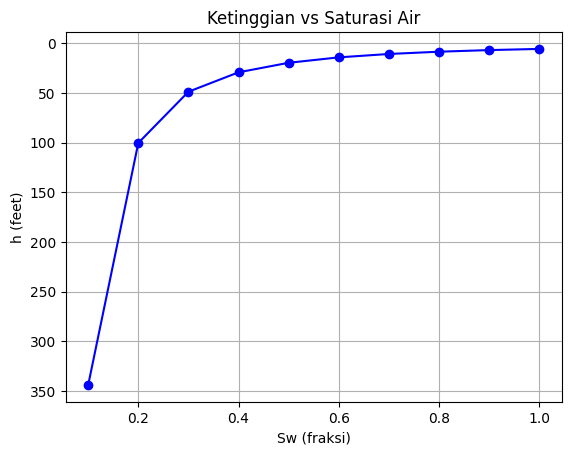

In [82]:
plt.figure()
plt.plot(df_h['Sw'], df_h['h (feet)'], 'bo-')
plt.xlabel('Sw (fraksi)'); plt.ylabel('h (feet)')
plt.title('Ketinggian vs Saturasi Air')
plt.gca().invert_yaxis()   # agar FWL di bawah
plt.grid(True)
plt.savefig('h_vs_Sw.png')
plt.show()

## PR Nomor 2

In [83]:
k_abs = 178
L_cm = 6 * 2.54
r_cm = (1.5/2) * 2.54
A_cm2 = 3.1416 * r_cm**2

q_w = 0.78 / 60
q_o = 1.21 / 60
mu_w = 1
mu_o = 0.93
dP_atm = 5 / 14.7

k_w_darcy = (q_w * mu_w * L_cm) / (A_cm2 * dP_atm)
k_o_darcy = (q_o * mu_o * L_cm) / (A_cm2 * dP_atm)

k_w_mD = k_w_darcy * 1000
k_o_mD = k_o_darcy * 1000
krw = k_w_mD / k_abs
kro = k_o_mD / k_abs

print("=== HASIL SOAL 2 ===")
print(f"a) Permeabilitas efektif air (k_w) = {k_w_mD:.2f} mD")
print(f"   Permeabilitas efektif minyak (k_o) = {k_o_mD:.2f} mD")
print(f"b) Permeabilitas relatif air (k_rw) = {krw:.3f}")
print(f"   Permeabilitas relatif minyak (k_ro) = {kro:.3f}")

df_soal2 = pd.DataFrame({
    'Parameter': ['k_abs (mD)', 'k_w efektif (mD)', 'k_o efektif (mD)', 'k_rw', 'k_ro'],
    'Nilai': [k_abs, k_w_mD, k_o_mD, krw, kro]
})
print("\nTabel ringkasan:")
print(df_soal2)

=== HASIL SOAL 2 ===
a) Permeabilitas efektif air (k_w) = 51.09 mD
   Permeabilitas efektif minyak (k_o) = 73.71 mD
b) Permeabilitas relatif air (k_rw) = 0.287
   Permeabilitas relatif minyak (k_ro) = 0.414

Tabel ringkasan:
          Parameter       Nilai
0        k_abs (mD)  178.000000
1  k_w efektif (mD)   51.089870
2  k_o efektif (mD)   73.706963
3              k_rw    0.287022
4              k_ro    0.414084
